In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

In [28]:
df = pd.read_csv("FraudShield_Banking_Data.csv")

In [37]:
df.head()

,Transaction_ID,Customer_ID,Transaction_Amount (in Million),Transaction_Time,Transaction_Date,Transaction_Type,Merchant_ID,Merchant_Category,Transaction_Location,Customer_Home_Location,...,Daily_Transaction_Count,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Is_International_Transaction,Is_New_Merchant,Failed_Transaction_Count,Unusual_Time_Transaction,Previous_Fraud_Count,Fraud_Label
0,431438.0,24239.0,6.0,10:54,2025-03-08,POS,97028.0,ATM,Singapore,Lahore,...,4.0,17.0,2.0,4.0,Yes,Yes,0.0,No,1.0,Normal
1,902451.0,77250.0,9.0,19:23,2025-01-17,ATM,27515.0,ATM,Singapore,Lahore,...,4.0,9.0,5.0,8.0,Yes,Yes,1.0,No,1.0,Normal
2,223410.0,34294.0,3.0,10:20,2025-04-30,POS,13810.0,Electronics,Faisalabad,Faisalabad,...,5.0,18.0,5.0,8.0,Yes,No,0.0,Yes,1.0,Normal
3,145626.0,92041.0,1.0,14:11,2025-02-21,Online,10501.0,Grocery,London,Karachi,...,6.0,18.0,5.0,1.0,No,Yes,2.0,Yes,1.0,Normal
4,414637.0,71578.0,1.0,04:12,2025-04-11,Online,53569.0,Electronics,Singapore,Islamabad,...,3.0,18.0,4.0,3.0,No,Yes,1.0,No,1.0,Normal


In [32]:
#Task 1: Data Quality assesment.
print(df.dtypes)

df['Transaction_Date']= pd.to_datetime(df['Transaction_Date'])
print(df['Transaction_Date'].dtype)  #Should be datetime, other columns values can be objects and floats. 

Transaction_ID                           float64
Customer_ID                              float64
Transaction_Amount (in Million)          float64
Transaction_Time                          object
Transaction_Date                          object
Transaction_Type                          object
Merchant_ID                              float64
Merchant_Category                         object
Transaction_Location                      object
Customer_Home_Location                    object
Distance_From_Home                       float64
Device_ID                                float64
IP_Address                                object
Card_Type                                 object
Account_Balance (in Million)             float64
Daily_Transaction_Count                  float64
Weekly_Transaction_Count                 float64
Avg_Transaction_Amount (in Million)      float64
Max_Transaction_Last_24h (in Million)    float64
Is_International_Transaction              object
Is_New_Merchant     

In [33]:
#Task 2: Applying one missing value strategy.
df.isna()
df.isna().sum() 
#There are no missing values in my dataset.

Transaction_ID                            3
Customer_ID                              10
Transaction_Amount (in Million)           9
Transaction_Time                          9
Transaction_Date                          3
Transaction_Type                          4
Merchant_ID                               7
Merchant_Category                         9
Transaction_Location                      6
Customer_Home_Location                    4
Distance_From_Home                        2
Device_ID                                 9
IP_Address                                6
Card_Type                                 3
Account_Balance (in Million)              9
Daily_Transaction_Count                   9
Weekly_Transaction_Count                  5
Avg_Transaction_Amount (in Million)       9
Max_Transaction_Last_24h (in Million)     4
Is_International_Transaction              4
Is_New_Merchant                           5
Failed_Transaction_Count                 11
Unusual_Time_Transaction        

In [36]:
#Applying the Removing records strategy, because it is only 11 records or less. 
df= df.dropna()
print('DF with null values shape: ', df.shape)
print('DF without null values shape: ', df.shape) 
print('\n', df.isna().sum()) #Should be all 0s.

DF with null values shape:  (49850, 25)
DF without null values shape:  (49850, 25)

 Transaction_ID                           0
Customer_ID                              0
Transaction_Amount (in Million)          0
Transaction_Time                         0
Transaction_Date                         0
Transaction_Type                         0
Merchant_ID                              0
Merchant_Category                        0
Transaction_Location                     0
Customer_Home_Location                   0
Distance_From_Home                       0
Device_ID                                0
IP_Address                               0
Card_Type                                0
Account_Balance (in Million)             0
Daily_Transaction_Count                  0
Weekly_Transaction_Count                 0
Avg_Transaction_Amount (in Million)      0
Max_Transaction_Last_24h (in Million)    0
Is_International_Transaction             0
Is_New_Merchant                          0
Failed_Trans

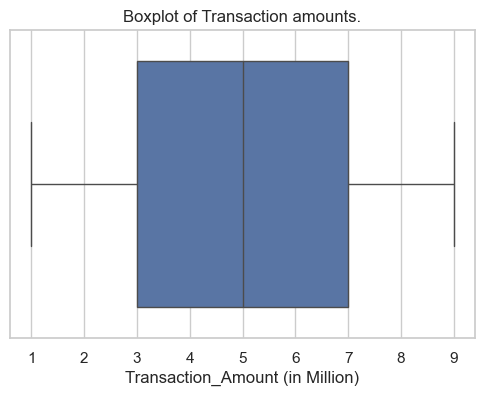

In [41]:
#Task 3: Detect and handle outliers using IQR.
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Transaction_Amount (in Million)'])
plt.title('Boxplot of Transaction amounts.')
plt.show() 

In [40]:
#The interquantile range method. 
Q1 = df['Transaction_Amount (in Million)'].quantile(0.25)
Q3 = df['Transaction_Amount (in Million)'].quantile(0.75)
IQR= Q3-Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Transaction_Amount (in Million)']<lower) | (df['Transaction_Amount (in Million)'] > upper)]
outliers.head(10) #Empty dataframe, nothing to handle. 

,Transaction_ID,Customer_ID,Transaction_Amount (in Million),Transaction_Time,Transaction_Date,Transaction_Type,Merchant_ID,Merchant_Category,Transaction_Location,Customer_Home_Location,...,Daily_Transaction_Count,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Is_International_Transaction,Is_New_Merchant,Failed_Transaction_Count,Unusual_Time_Transaction,Previous_Fraud_Count,Fraud_Label


In [42]:
#Task 4: Normalize numerical features using both Min-Max and Z-score 

#First: Min-Max method. 
df[['Transaction_Amount (in Million)', 'Daily_Transaction_Count']].head() 

,Transaction_Amount (in Million),Daily_Transaction_Count
0,6.0,4.0
1,9.0,4.0
2,3.0,5.0
3,1.0,6.0
4,1.0,3.0


In [43]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df[['Transaction_Amount (in Million)', 'Daily_Transaction_Count']].copy()
df_scaled[['Transaction_Amount (in Million)', 'Daily_Transaction_Count']] = scaler.fit_transform(df_scaled)
df_scaled.head()

,Transaction_Amount (in Million),Daily_Transaction_Count
0,0.625,0.500000
1,1.000,0.500000
2,0.250,0.666667
3,0.000,0.833333
4,0.000,0.333333


In [53]:
#z-score normalization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_standardized = df[['Transaction_Amount (in Million)', 'Daily_Transaction_Count']].copy()
df_standardized[['Transaction_Amount (in Million)', 'Daily_Transaction_Count']] = scaler.fit_transform(df_standardized)
df_standardized.head()

,Transaction_Amount (in Million),Daily_Transaction_Count
0,0.387497,0.000170
1,1.549547,0.000170
2,-0.774552,0.499536
3,-1.549252,0.998901
4,-1.549252,-0.499195


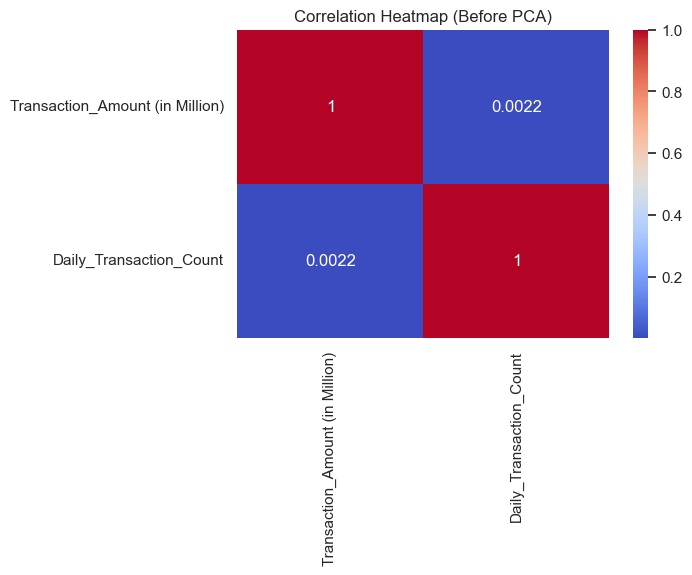

In [56]:
#Task 5: Apply PCA only if the numerical features show a correlation. 
plt.figure(figsize=(6,4))
sns.heatmap(df_standardized[['Transaction_Amount (in Million)', 'Daily_Transaction_Count']].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Before PCA)")
plt.show() 
#The two features have almost no linear relationship.

In [59]:
from sklearn.decomposition import PCA
X = df_standardized[['Transaction_Amount (in Million)', 'Daily_Transaction_Count']]
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.50111749 0.49888251]


Text(0.5, 1.0, 'PCA Projection')

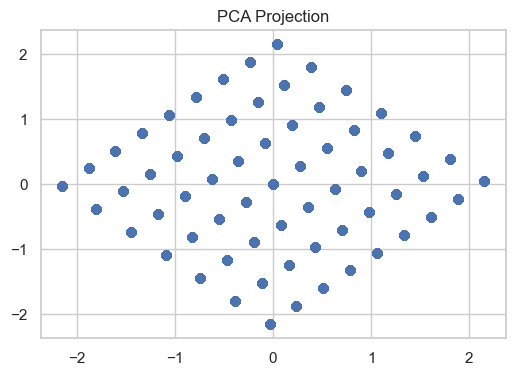

In [61]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")